# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [1]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("../data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [3]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()

#df.duplicated().sum() 
#df.value_counts()

# Count how many times 2000 appears in the 'msrp' column
#msrp_placeholder_count = (df['MSRP'] == 2000).sum()
#print(f"Number of rows affected: {msrp_placeholder_count}") 
# #1036 rows 2000 MSRP  

# df.describe() 
#df.nlargest(10, "highway MPG")[["Make", "Model", "Year", "highway MPG", "city mpg"]]
#df[(df["Make"] == "Audi") & (df["Model"] == "A6") & (df["Year"] == 2017)]

#df.isna().sum()
#df[df["Engine HP"].isna()]["Engine Fuel Type"].value_counts()
#df[df["Engine Cylinders"].isna()][["Make", "Model", "Year", "Engine Fuel Type"]]

#df[df["Engine Fuel Type"].isna()]      #engine fuel type NaN
#df[df["Number of Doors"].isna()]       # number of doors NaN

#df["Transmission Type"].value_counts()
#df["Transmission Type"].isna().sum()


**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 |duplicate rows |df.duplicated().sum() | 720 rows| dropped the duplicates | We don't need duplicate rows |
| 2 | Some 90s cars have 2000 MSRP | df.value_counts()| 1036 rows  | turned those 2000 msrp into NaNs | It was a placeholder value anyways|
| 3 | Highway MPG is 354 |df.describe() | 1 row (Audi A6 2017) | non electric cars cannot go over 100mpg | Its a car thing so it just would make more sense if it can't |
| 4 | NaNs in fields like doors and HP | df.isna().sum() and then looked deeper for which rows | 102  | Left it | It would erase too much info if I deleted all those rows |
| 5 | Transmission Type Unknown but not an NaN | df["Transmission Type"].value_counts() |19 | turned them into Nans : clean.loc[clean["transmission_type"] == "UNKNOWN", "transmission_type"] = np.nan  | It was incorrectly labeled before so you couldnt track if it was unknown. |

In [7]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean = clean.dropna()  # remove any rows with missing values

clean = clean.drop_duplicates()  # remove dupes
clean = clean.reset_index(drop=True)  # reset index after dropping duplicates and missing values

clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names


clean.loc[clean["msrp"] == 2000, "msrp"] = np.nan

isElectric = clean["engine_fuel_type"] == "electric"
impossibleMpg = (~isElectric) & (clean["highway_mpg"] > 100)
clean.loc[impossibleMpg, "highway_mpg"] = np.nan

clean.loc[clean["transmission_type"] == "UNKNOWN", "transmission_type"] = np.nan




In [8]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11092, 15)
transmission_type     12
highway_mpg            1
msrp                 747
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

Mean: $44,790   Median: $31,810


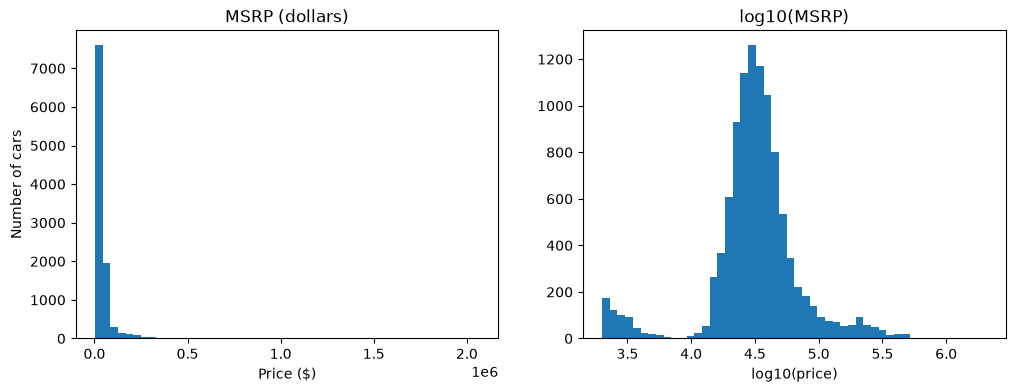

24.4% of cars cost more than the mean


In [9]:
# a) mean and median
validPrices = clean["msrp"].dropna()
meanPrice = validPrices.mean()
medianPrice = validPrices.median()
print(f"Mean: ${meanPrice:,.0f}   Median: ${medianPrice:,.0f}")   

# ANSWER FOR A : THE MEAN IS LARGER BECAUSE THE MEAN ACCOUNTS FOR THE AVERAGE OF ALL PRICES AND SPITS OUT A NUMBER. 
# THE MEDIAN INSTEAD TAKES THE VERY MIDDLE VALUE OF ALL THE VALUES TO REPRESENT ITSELF.   

# b) two histograms side by side (plt.subplots(1, 2))

figure, (axisRawPrice, axisLogPrice) = plt.subplots(1, 2, figsize=(12, 4))

axisRawPrice.hist(validPrices, bins=50) # bins means how many bars to split the range into
axisRawPrice.set_title("MSRP (dollars)")
axisRawPrice.set_xlabel("Price ($)")
axisRawPrice.set_ylabel("Number of cars")

axisLogPrice.hist(np.log10(validPrices), bins=50) 
axisLogPrice.set_title("log10(MSRP)")
axisLogPrice.set_xlabel("log10(price)")

plt.show()

# c) share of cars above the mean

shareAboveMean = (validPrices > meanPrice).mean()
print(f"{shareAboveMean:.1%} of cars cost more than the mean")

** D Answer: The hopepage should have the median because it is a more representative number of the usual price of the cars at MSRP **

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [10]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only

cars2017 = clean[(clean["year"] == 2017) & (clean["engine_fuel_type"] != "electric")]
cars2017 = cars2017.dropna(subset=["highway_mpg"]).copy()
print(len(cars2017))

mpgStatsBySize = cars2017.groupby("vehicle_size")["highway_mpg"].agg(["count", "mean", "std"])
print(mpgStatsBySize)

# b) z = (value - class mean) / class std

# .loc[row label, column label]
compactMean = mpgStatsBySize.loc["Compact", "mean"]
compactStd  = mpgStatsBySize.loc["Compact", "std"]
largeMean   = mpgStatsBySize.loc["Large", "mean"]
largeStd    = mpgStatsBySize.loc["Large", "std"]

civicZScore = (42 - compactMean) / compactStd    
volvoZScore = (34 - largeMean) / largeStd       
print(f"Civic z = {civicZScore:.2f}   Volvo S90 z = {volvoZScore:.2f}")

compactAtOrAbove42 = (cars2017.loc[cars2017["vehicle_size"] == "Compact", "highway_mpg"] >= 42).sum()   # 15 of 505 (3.0%)
largeAtOrAbove34   = (cars2017.loc[cars2017["vehicle_size"] == "Large",   "highway_mpg"] >= 34).sum()   # 2 of 462 (0.4%)

1601
              count       mean       std
vehicle_size                            
Compact         505  30.895050  6.066339
Large           462  22.956710  3.498724
Midsize         634  29.356467  5.426434
Civic z = 1.83   Volvo S90 z = 3.16


**Answer: The Volvo S90 is. It's 3.16 standard deviations above its class, versus 1.83 for the Civic. **

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

n = 1605, observed median = $36,720
95% interval: $35,890 to $37,695


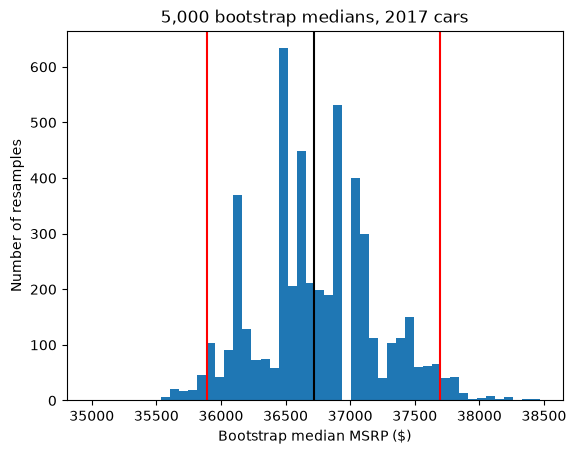

Lexus: n = 34, median = $47,615, 95% interval = $42,770 to $53,035


In [14]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    # hint: rng.choice(values, size=len(values), replace=True)
    valuesArray = np.asarray(values)
    sampleSize = len(valuesArray)  
    bootstrapMedians = np.empty(n_boot)

    for i in range(n_boot):
        resample = rng.choice(valuesArray, size=sampleSize, replace=True)
        bootstrapMedians[i] = np.median(resample)  # median of this one fake market

    return bootstrapMedians
    pass

# a, b)
prices2017 = clean.loc[clean["year"] == 2017, "msrp"].dropna()
observedMedian = prices2017.median()
print(f"n = {len(prices2017)}, observed median = ${observedMedian:,.0f}")
#b) 

bootMedians = bootstrap_median(prices2017)
lowerBound, upperBound = np.percentile(bootMedians, [2.5, 97.5])
print(f"95% interval: ${lowerBound:,.0f} to ${upperBound:,.0f}")

plt.hist(bootMedians, bins=50)
plt.axvline(lowerBound, color="red")                  # interval edges
plt.axvline(upperBound, color="red")
plt.axvline(observedMedian, color="black")            # the real median
plt.xlabel("Bootstrap median MSRP ($)")
plt.ylabel("Number of resamples")
plt.title("5,000 bootstrap medians, 2017 cars")
plt.show()
# c) For Lexus 2017 the median is about $47,615 with a 95% interval of about $42,770 to $52,630. 
# This is much wider than the full-market interval. With fewer cars, a few unusual prices can move the median a lot, 
# so the estimate is less certain. (Price spread also matters: a small make with very similar prices can still
# have a narrow interval.)

lexusPrices2017 = clean.loc[(clean["year"] == 2017) & (clean["make"] == "Lexus"), "msrp"].dropna()
lexusBootMedians = bootstrap_median(lexusPrices2017)
lexusLower, lexusUpper = np.percentile(lexusBootMedians, [2.5, 97.5])
print(f"Lexus: n = {len(lexusPrices2017)}, median = ${lexusPrices2017.median():,.0f}, "
      f"95% interval = ${lexusLower:,.0f} to ${lexusUpper:,.0f}")

#d ) - If the 2017 market had come out slightly different, the typical price would most likely fall 
# between about $35,900 and $37,700, so quoting $36,700 as the typical price is reliable.



**Answer:**

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

n = 505
mean = 30.90, median = 30.0, std = 6.07, skew = 0.57


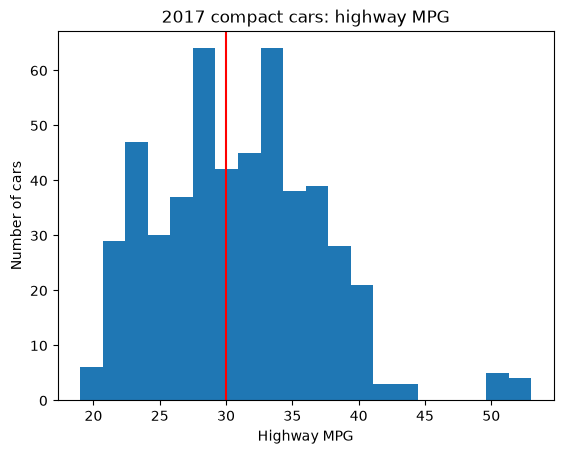

t = 3.32, p = 0.00049
make        model   
Toyota      Tacoma      27
Chevrolet   Corvette    24
Nissan      Frontier    22
            370Z        17
Porsche     911         14
Honda       Civic       13
Audi        A3          12
Volkswagen  Golf GTI    10
dtype: int64
85 models, median 6 rows each, max 27
n = 85, mean = 31.69, t = 2.58, p = 0.0059


In [15]:
# a) a) H₀: μ = 30. Hₐ: μ > 30. It's one-sided because the claim is "over 30". 

# H₀: the true average highway MPG of 2017 compacts is 30 (μ = 30).
# Hₐ: the true average is greater than 30 (μ > 30).
# One-sided because marketing's claim is specifically "over 30". 
# Only evidence in that direction can support it, and you have to choose the direction before looking at the data.

# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram

compactCars2017 = clean[(clean["year"] == 2017)
                        & (clean["vehicle_size"] == "Compact")
                        & (clean["engine_fuel_type"] != "electric")]
compactCars2017 = compactCars2017.dropna(subset=["highway_mpg"]).copy()
highwayMpgCompact = compactCars2017["highway_mpg"]  

print(f"n = {len(highwayMpgCompact)}")
print(f"mean = {highwayMpgCompact.mean():.2f}, median = {highwayMpgCompact.median():.1f}, "
      f"std = {highwayMpgCompact.std():.2f}, skew = {stats.skew(highwayMpgCompact):.2f}")

plt.hist(highwayMpgCompact, bins=20)
plt.axvline(30, color="red")                             
plt.xlabel("Highway MPG")
plt.ylabel("Number of cars")
plt.title("2017 compact cars: highway MPG")
plt.show()

# c) one-sample t-test vs 30
tTestResult = stats.ttest_1samp(highwayMpgCompact, 30, alternative="greater")
print(f"t = {tTestResult.statistic:.2f}, p = {tTestResult.pvalue:.5f}")


# d) rows per make+model, then one row per model and retest

rowsPerModel = compactCars2017.groupby(["make", "model"]).size().sort_values(ascending=False)
print(rowsPerModel.head(8))
print(f"{len(rowsPerModel)} models, median {rowsPerModel.median():.0f} rows each, max {rowsPerModel.max()}")

# Average highway MPG to ONE value per model, then rerun the same test
mpgPerModel = compactCars2017.groupby(["make", "model"])["highway_mpg"].mean()
perModelResult = stats.ttest_1samp(mpgPerModel, 30, alternative="greater")
print(f"n = {len(mpgPerModel)}, mean = {mpgPerModel.mean():.2f}, "
      f"t = {perModelResult.statistic:.2f}, p = {perModelResult.pvalue:.4f}")

**Answer: # H₀: the true average highway MPG of 2017 compacts is 30 (μ = 30).
 Hₐ: the true average is greater than 30 (μ > 30).
 One-sided because marketing's claim is specifically "over 30". 
 Only evidence in that direction can support it, and you have to choose the direction before looking at the data.
**

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [18]:
# a) compare median MSRP by transmission type
autoVsManual = clean[clean["transmission_type"].isin(["AUTOMATIC", "MANUAL"])]

# groupby splits into two piles, then we summarize msrp in each (median skips NaN automatically)
medianPriceByTransmission = autoVsManual.groupby("transmission_type")["msrp"].median()
print(medianPriceByTransmission)

# b) compare year by transmission type
yearByTransmission = autoVsManual.groupby("transmission_type")["year"].agg(["median", "mean"])
print(yearByTransmission)

# Share of each group that is from the 1990s (True counts as 1, so .mean() is the fraction)
nineties = (autoVsManual["year"] <= 1999)
print(nineties.groupby(autoVsManual["transmission_type"]).mean())

# c) compare 2015-2017 medians overall and within each vehicle_size
# For 2015-17 compacts, test automatic vs manual prices with:
# stats.mannwhitneyu(auto, manual)

recentCars = autoVsManual[autoVsManual["year"].between(2015, 2017)]

print(recentCars.groupby("transmission_type")["msrp"].median())

print(recentCars.pivot_table(index="vehicle_size", columns="transmission_type",
                             values="msrp", aggfunc=["count", "median"]))

compactRecent = recentCars[recentCars["vehicle_size"] == "Compact"]
autoPrices   = compactRecent.loc[compactRecent["transmission_type"] == "AUTOMATIC", "msrp"].dropna()
manualPrices = compactRecent.loc[compactRecent["transmission_type"] == "MANUAL", "msrp"].dropna()
mannWhitneyResult = stats.mannwhitneyu(autoPrices, manualPrices)
print(f"U = {mannWhitneyResult.statistic:.0f}, p = {mannWhitneyResult.pvalue:.3f}")

transmission_type
AUTOMATIC    33627.5
MANUAL       21810.0
Name: msrp, dtype: float64
                   median         mean
transmission_type                     
AUTOMATIC          2015.0  2011.841885
MANUAL             2008.0  2006.476718
transmission_type
AUTOMATIC    0.062207
MANUAL       0.286641
Name: year, dtype: float64
transmission_type
AUTOMATIC    37037.5
MANUAL       26905.0
Name: msrp, dtype: float64
                      count           median         
transmission_type AUTOMATIC MANUAL AUTOMATIC   MANUAL
vehicle_size                                         
Compact                1115    589   25995.0  25860.0
Large                  1463     26   44410.0  38395.0
Midsize                1914    198   37962.5  26920.0
U = 315961, p = 0.199


**Answer: 
(a) Overall median MSRP is about $33,628 for automatics and $21,810 for manuals, so manuals look about $11,800 cheaper.
(b) Manual cars are much older (median year 2008 versus 2015; 29% are from the 1990s versus 6% of automatics), and older cars have lower sticker prices, so age confounds the comparison.
(c) For 2015–2017 cars the gap shrinks but remains overall ($26,905 vs $37,038), largely because manuals are concentrated in cheaper compacts (72% of manuals vs 25% of automatics). Within Compacts the medians are almost identical ($25,860 manual vs $25,995 automatic) and Mann–Whitney gives p ≈ 0.20, so there's no evidence of a price difference. Midsize cars still show a gap, which differences in body style (many more SUVs among automatics) may partly explain.
(d) Manuals look about $11,000 cheaper, but that is mostly because they're older and smaller; among comparable 2015–2017 compacts prices are basically the same, so I wouldn't push manuals as the budget option. **

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [ ]:
# a) Welch t-test, 4-door vs 2-door
trustedCars = clean[(clean["engine_fuel_type"] != "electric")
                    & (clean["number_of_doors"].isin([2, 4]))]
trustedCars = trustedCars.dropna(subset=["highway_mpg"])

fourDoorMpg = trustedCars.loc[trustedCars["number_of_doors"] == 4, "highway_mpg"]
twoDoorMpg  = trustedCars.loc[trustedCars["number_of_doors"] == 2, "highway_mpg"]

welchResult = stats.ttest_ind(fourDoorMpg, twoDoorMpg, equal_var=False)
mpgDifference = fourDoorMpg.mean() - twoDoorMpg.mean()
print(f"4-door: {fourDoorMpg.mean():.2f} (n={len(fourDoorMpg)}), 2-door: {twoDoorMpg.mean():.2f} (n={len(twoDoorMpg)})")
print(f"difference = {mpgDifference:.2f} MPG, t = {welchResult.statistic:.2f}, p = {welchResult.pvalue:.2e}")

# b) yearly gas cost = miles * price_per_gallon / mpg
milesPerYear = 12000
pricePerGallon = 3.50

yearlyGasCostFourDoor = milesPerYear * pricePerGallon / fourDoorMpg.mean()
yearlyGasCostTwoDoor  = milesPerYear * pricePerGallon / twoDoorMpg.mean()
yearlySavings = yearlyGasCostTwoDoor - yearlyGasCostFourDoor
print(f"4-door ${yearlyGasCostFourDoor:,.0f}, 2-door ${yearlyGasCostTwoDoor:,.0f}, saving ${yearlySavings:,.0f} per year")

# c) simulation
fourDoorArray = fourDoorMpg.to_numpy()
twoDoorArray = twoDoorMpg.to_numpy()

n_sims, hits = 1000, 0
for _ in range(n_sims):
    smallSampleFour = rng.choice(fourDoorArray, 30, replace=False)
    smallSampleTwo  = rng.choice(twoDoorArray, 30, replace=False)
    smallTestResult = stats.ttest_ind(smallSampleFour, smallSampleTwo, equal_var=False)
    if smallTestResult.pvalue < 0.05:
        hits += 1
    pass

print(f"{hits} of {n_sims} small studies were significant ({hits / n_sims:.1%})")


4-door: 26.81 (n=7852), 2-door: 25.26 (n=2870)
difference = 1.55 MPG, t = 11.96, p = 1.52e-32
4-door $1,566, 2-door $1,663, saving $96 per year
157 of 1000 small studies were significant (15.7%)


**Answer:
(a) 4-door cars average 26.81 highway MPG versus 25.26 for 2-door cars, a difference of about 1.55 MPG (Welch t ≈ 11.96, p ≈ 1.5×10⁻³²). The difference is statistically significant, but small (Cohen's d ≈ 0.25).
(b) At 12,000 miles a year and $3.50 a gallon, the average 4-door driver spends about $1,566 on gas versus $1,663 for a 2-door driver, a savings of roughly $96 a year (about $100).
(c) With only 30 cars per group, only about 16–18% of the 1,000 simulated studies came out significant, so a small study would usually miss a real difference of this size. Significance depends on sample size, not just effect size.
(d) I would not say "significantly more fuel-efficient" in an ad, since customers would read it as a large difference when it is worth about $100 a year, and door count is tied to body style and model year, so it is not clear that doors cause the gain. I'd say: "4-door cars in our listings average about 1.5 more highway MPG, roughly $100 a year in gas."**

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo: Manual cars look cheaper, with a median sticker price of about $21,800 versus $33,600 for automatics, but that gap is mostly misleading. Manuals in our data are older (median model year 2008 versus 2015) and mostly small cars (72% of 2015–2017 manuals are compacts versus 25% of automatics), and older, smaller cars simply have lower prices. When I compare only 2015–2017 compacts, the median prices are nearly identical ($25,860 for manual versus $25,995 for automatic). A statistical test agrees: a gap that small would show up by luck alone about 1 time in 5, so there's no clear price difference and I would not pitch manuals to budget shoppers as the cheaper choice. Separately, when we quote a "typical" price we should use the median (about $31,800) rather than the average ($44,800), because a handful of exotic cars (six priced over $1 million) pull the average up. One limitation is that about 750 listings of 1990–2000 cars carried an identical placeholder price of $2,000, which I removed as unreliable, and manuals were hit harder (17% of manuals had no usable price versus 4% of automatics), so our picture of older manual prices is thin. **

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [ ]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [ ]:
# S2